# 7. Vizualizacija i analiza podataka

Ovaj notebook provodi analizu podataka iz dimenzijskog modela (star sheme) pomocu SQL upita i Python vizualizacija.

**KPI-evi:**
1. Broj ticketa po projektu
2. Prosjecno vrijeme rjesavanja po prioritetu
3. Mjesecni trend volumena ticketa
4. Raspodjela workflow vremena (open / in_progress / waiting)
5. Top 10 tehnicara po opterecenju
6. Analiza rezolucija po projektu

**Preduvjeti:** Pokrenuti notebookove 5 (DDL) i 6 (ETL).

In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

load_dotenv()

DB_USER = os.getenv('DB_USER', 'root')
DB_PASSWORD = os.getenv('DB_PASSWORD')
DB_HOST = os.getenv('DB_HOST', 'localhost')
DB_NAME = os.getenv('DB_NAME', 'fipu_srp_projekt')

if not DB_PASSWORD:
    raise ValueError("DB_PASSWORD nije postavljen!")

engine = create_engine(f"mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}/{DB_NAME}")
print(f"Spojeno na bazu: {DB_NAME}")

# Stil grafova
plt.rcParams.update({
    'figure.figsize': (12, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

Spojeno na bazu: fipu_srp_projekt


## 7.1 Broj ticketa po projektu

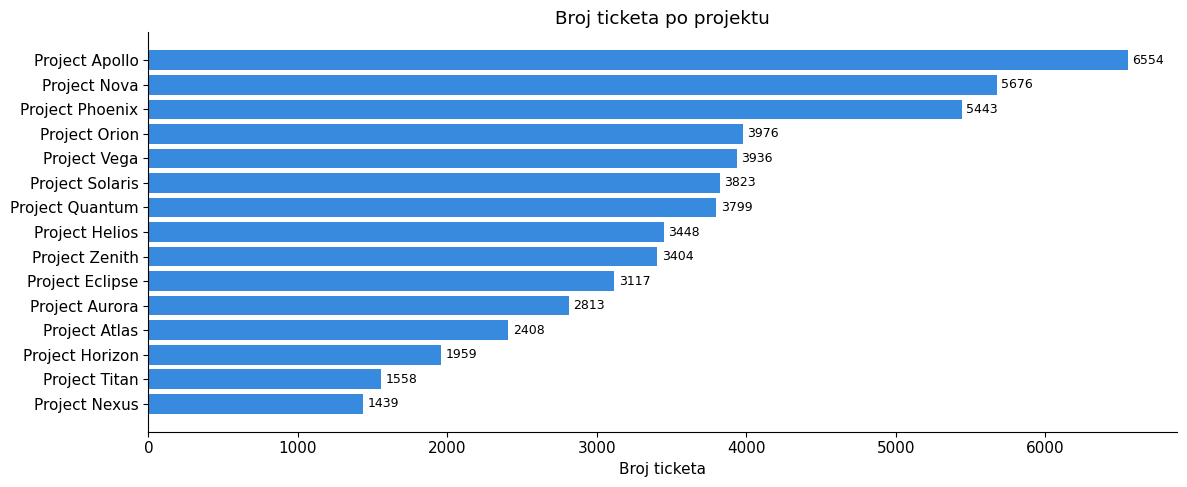

In [4]:
df1 = pd.read_sql("""
    SELECT p.naziv_projekta AS projekt, COUNT(*) AS broj_ticketa
    FROM fact_support_tickets f
    JOIN dim_projekt p ON f.projekt_key = p.projekt_key
    GROUP BY p.naziv_projekta
    ORDER BY broj_ticketa DESC
""", engine)

fig, ax = plt.subplots()
bars = ax.barh(df1['projekt'], df1['broj_ticketa'], color='#378ADD')
ax.set_xlabel('Broj ticketa')
ax.set_title('Broj ticketa po projektu')
ax.invert_yaxis()
for bar, val in zip(bars, df1['broj_ticketa']):
    ax.text(val + 30, bar.get_y() + bar.get_height()/2, str(val), va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 7.2 Prosjecno vrijeme rjesavanja po prioritetu

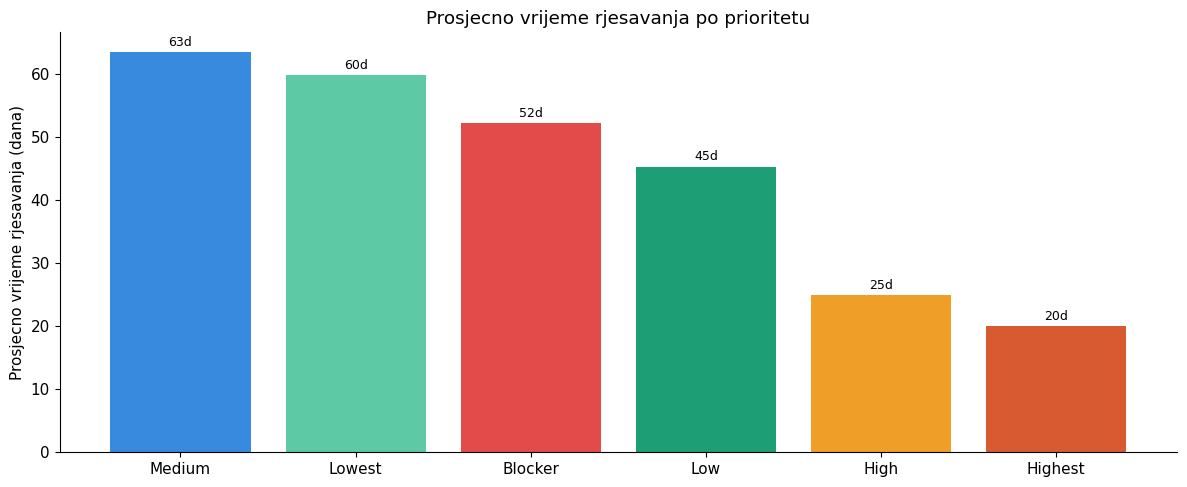

prioritet  broj_ticketa  avg_sati  avg_dana
   Medium         19459    1521.2      63.4
   Lowest            70    1435.4      59.8
  Blocker           513    1253.7      52.2
      Low           418    1086.9      45.3
     High          3453     597.4      24.9
  Highest          1586     480.8      20.0


In [5]:
df2 = pd.read_sql("""
    SELECT ps.razina_prioriteta AS prioritet,
           COUNT(*) AS broj_ticketa,
           ROUND(AVG(f.vrijeme_rjesavanja_sati), 1) AS avg_sati,
           ROUND(AVG(f.vrijeme_rjesavanja_sati) / 24, 1) AS avg_dana
    FROM fact_support_tickets f
    JOIN dim_prioritet ps ON f.prioritet_key = ps.prioritet_key
    WHERE f.vrijeme_rjesavanja_sati IS NOT NULL
      AND ps.razina_prioriteta != 'unknown'
    GROUP BY ps.razina_prioriteta
    ORDER BY avg_sati DESC
""", engine)

fig, ax = plt.subplots()
colors = {'Blocker':'#E24B4A', 'Highest':'#D85A30', 'High':'#EF9F27',
          'Medium':'#378ADD', 'Low':'#1D9E75', 'Lowest':'#5DCAA5'}
bar_colors = [colors.get(p, '#888780') for p in df2['prioritet']]
bars = ax.bar(df2['prioritet'], df2['avg_dana'], color=bar_colors)
ax.set_ylabel('Prosjecno vrijeme rjesavanja (dana)')
ax.set_title('Prosjecno vrijeme rjesavanja po prioritetu')
for bar, val in zip(bars, df2['avg_dana']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 1, f'{val:.0f}d', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

print(df2.to_string(index=False))

## 7.3 Mjesecni trend volumena ticketa

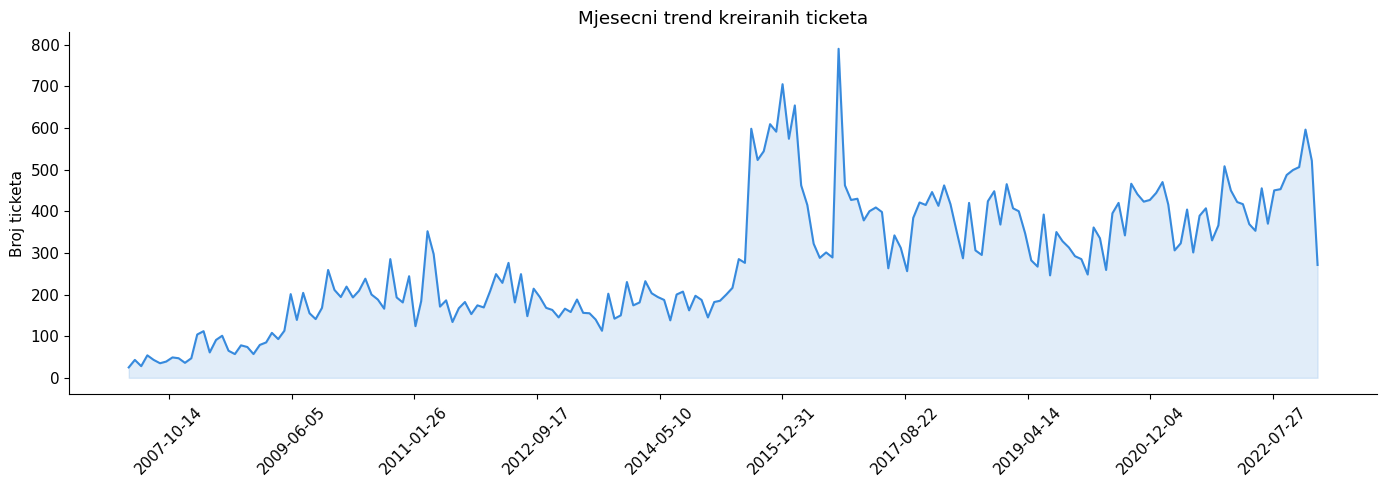

In [6]:
df3 = pd.read_sql("""
    SELECT v.godina, v.mjesec, COUNT(*) AS broj_ticketa
    FROM fact_support_tickets f
    JOIN dim_vrijeme v ON f.vrijeme_key = v.vrijeme_key
    GROUP BY v.godina, v.mjesec
    ORDER BY v.godina, v.mjesec
""", engine)

df3['datum'] = pd.to_datetime(df3['godina'].astype(str) + '-' + df3['mjesec'].astype(str))

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df3['datum'], df3['broj_ticketa'], color='#378ADD', linewidth=1.5)
ax.fill_between(df3['datum'], df3['broj_ticketa'], alpha=0.15, color='#378ADD')
ax.set_ylabel('Broj ticketa')
ax.set_title('Mjesecni trend kreiranih ticketa')
ax.xaxis.set_major_locator(mticker.MaxNLocator(12))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 7.4 Raspodjela workflow vremena

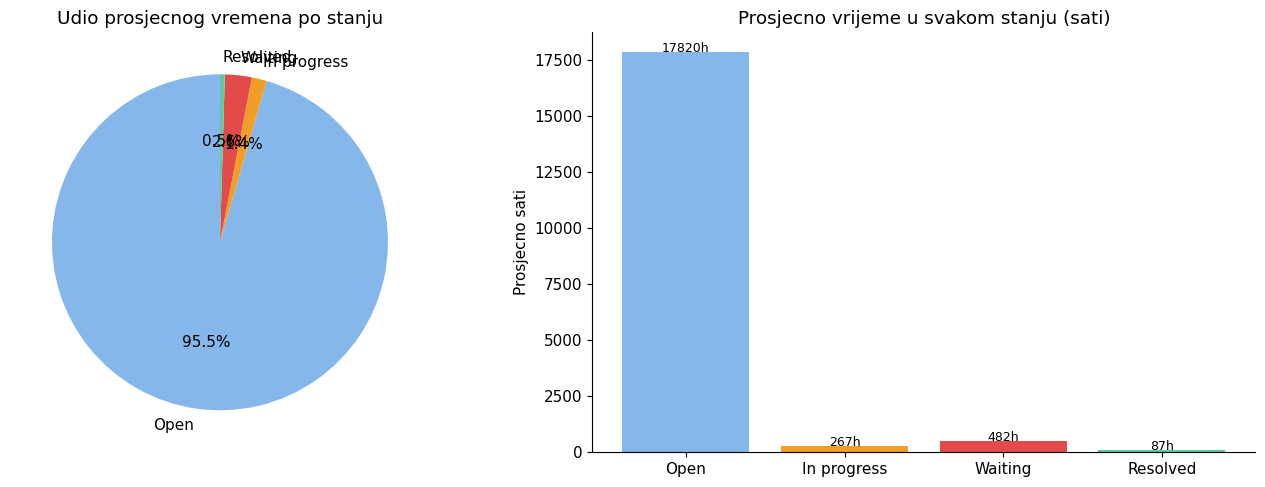

In [7]:
df4 = pd.read_sql("""
    SELECT
        ROUND(AVG(f.sati_open), 1) AS avg_open,
        ROUND(AVG(f.sati_in_progress), 1) AS avg_in_progress,
        ROUND(AVG(f.sati_resolved), 1) AS avg_resolved,
        ROUND(AVG(f.sati_waiting), 1) AS avg_waiting
    FROM fact_support_tickets f
    WHERE f.sati_open IS NOT NULL
""", engine)

labels = ['Open', 'In progress', 'Waiting', 'Resolved']
values = [df4['avg_open'].iloc[0], df4['avg_in_progress'].iloc[0],
          df4['avg_waiting'].iloc[0], df4['avg_resolved'].iloc[0]]
colors = ['#85B7EB', '#EF9F27', '#E24B4A', '#5DCAA5']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
ax1.pie(values, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
ax1.set_title('Udio prosjecnog vremena po stanju')

# Bar chart (sati)
bars = ax2.bar(labels, values, color=colors)
ax2.set_ylabel('Prosjecno sati')
ax2.set_title('Prosjecno vrijeme u svakom stanju (sati)')
for bar, val in zip(bars, values):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 5, f'{val:.0f}h', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 7.5 Top 10 tehnicara po opterecenju

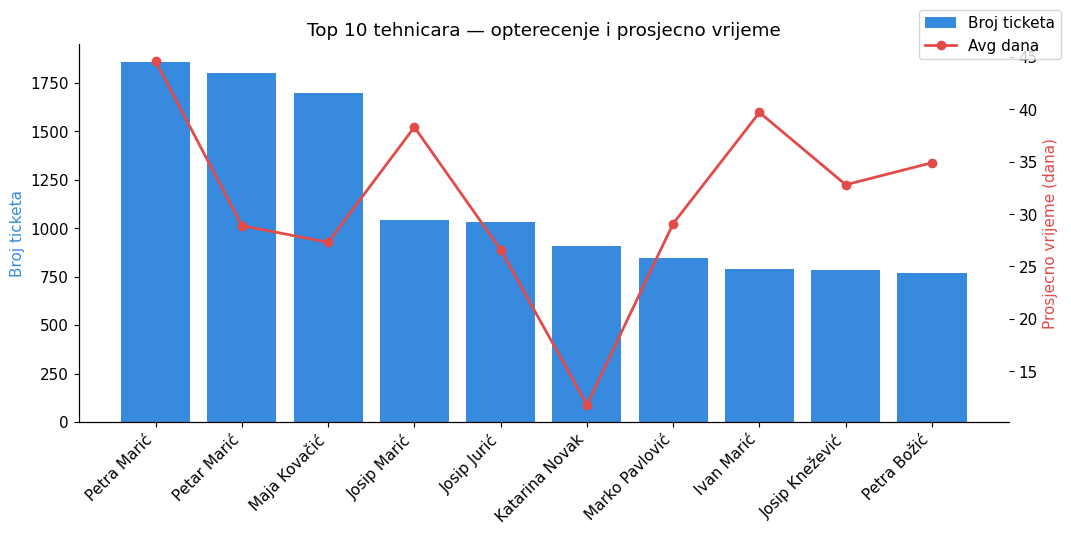

In [8]:
df5 = pd.read_sql("""
    SELECT t.ime_prezime AS tehnicar,
           COUNT(*) AS broj_ticketa,
           ROUND(AVG(f.vrijeme_rjesavanja_sati) / 24, 1) AS avg_dana
    FROM fact_support_tickets f
    JOIN dim_tehnicar t ON f.assignee_key = t.tehnicar_key
    GROUP BY t.ime_prezime
    ORDER BY broj_ticketa DESC
    LIMIT 10
""", engine)

fig, ax1 = plt.subplots(figsize=(12, 6))
x = range(len(df5))
bars = ax1.bar(x, df5['broj_ticketa'], color='#378ADD', label='Broj ticketa')
ax1.set_ylabel('Broj ticketa', color='#378ADD')
ax1.set_title('Top 10 tehnicara — opterecenje i prosjecno vrijeme')
ax1.set_xticks(x)
ax1.set_xticklabels(df5['tehnicar'], rotation=45, ha='right')

ax2 = ax1.twinx()
ax2.plot(x, df5['avg_dana'], color='#E24B4A', marker='o', linewidth=2, label='Avg dana')
ax2.set_ylabel('Prosjecno vrijeme (dana)', color='#E24B4A')

fig.legend(loc='upper right', bbox_to_anchor=(0.95, 0.95))
plt.subplots_adjust(bottom=0.25)
plt.show()

## 7.6 Analiza rezolucija po projektu

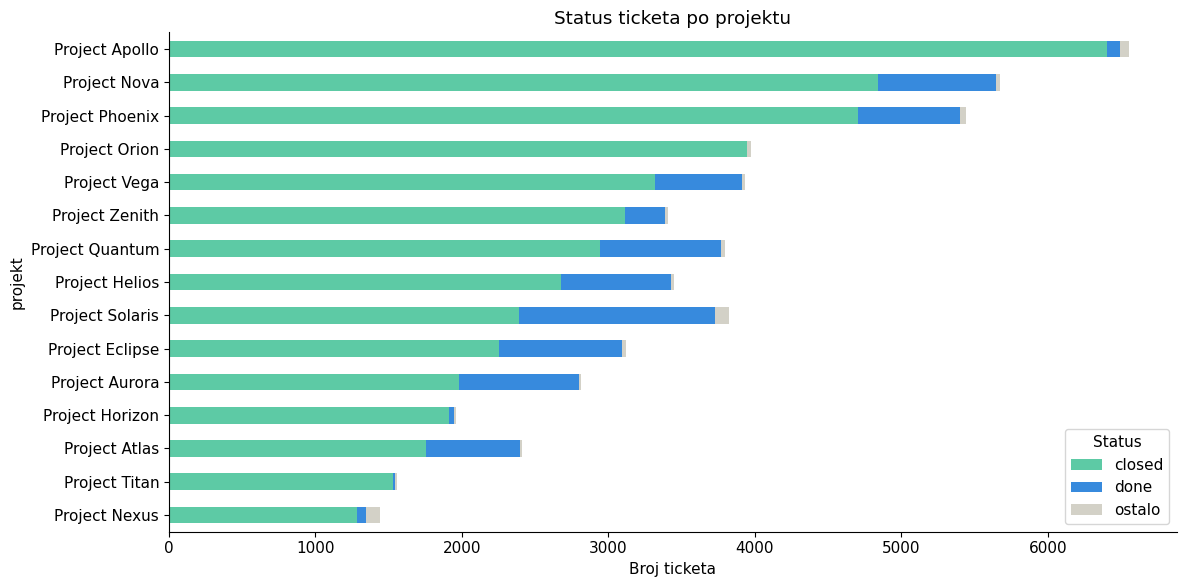

In [9]:
df6 = pd.read_sql("""
    SELECT p.naziv_projekta AS projekt, s.naziv_statusa AS status,
           COUNT(*) AS cnt
    FROM fact_support_tickets f
    JOIN dim_projekt p ON f.projekt_key = p.projekt_key
    JOIN dim_status s ON f.status_key = s.status_key
    GROUP BY p.naziv_projekta, s.naziv_statusa
    ORDER BY p.naziv_projekta, cnt DESC
""", engine)

# Pivot za stacked bar
pivot = df6.pivot_table(index='projekt', columns='status', values='cnt', fill_value=0)

# Odaberi top statuse (closed, done, ostali grupirani)
top_statuses = ['closed', 'done']
other_cols = [c for c in pivot.columns if c not in top_statuses]
pivot['ostalo'] = pivot[other_cols].sum(axis=1)
plot_df = pivot[top_statuses + ['ostalo']].sort_values('closed', ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))
plot_df.plot(kind='barh', stacked=True, ax=ax, color=['#5DCAA5', '#378ADD', '#D3D1C7'])
ax.set_xlabel('Broj ticketa')
ax.set_title('Status ticketa po projektu')
ax.legend(title='Status')
plt.tight_layout()
plt.show()

## 7.7 Ticketi po danu u tjednu i kvartalu (heatmap)

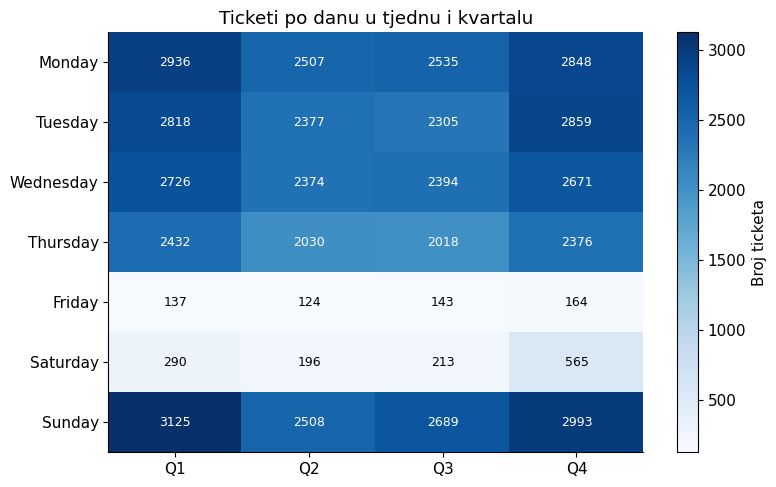

In [10]:
df7 = pd.read_sql("""
    SELECT v.dan_u_tjednu, v.kvartal, COUNT(*) AS cnt
    FROM fact_support_tickets f
    JOIN dim_vrijeme v ON f.vrijeme_key = v.vrijeme_key
    GROUP BY v.dan_u_tjednu, v.kvartal
""", engine)

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot = df7.pivot_table(index='dan_u_tjednu', columns='kvartal', values='cnt', fill_value=0)
pivot = pivot.reindex(day_order)

fig, ax = plt.subplots(figsize=(8, 5))
im = ax.imshow(pivot.values, cmap='Blues', aspect='auto')
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels([f'Q{q}' for q in pivot.columns])
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_title('Ticketi po danu u tjednu i kvartalu')

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        color = 'white' if val > pivot.values.max() * 0.6 else 'black'
        ax.text(j, i, f'{val:.0f}', ha='center', va='center', fontsize=9, color=color)

plt.colorbar(im, ax=ax, label='Broj ticketa')
plt.tight_layout()
plt.show()

## 7.8 Sazetak KPI-eva

In [11]:
kpi = pd.read_sql("""
    SELECT
        COUNT(*) AS ukupno_ticketa,
        COUNT(DISTINCT f.projekt_key) AS broj_projekata,
        COUNT(DISTINCT f.reporter_key) AS broj_reportera,
        COUNT(DISTINCT f.assignee_key) AS broj_assigneea,
        ROUND(AVG(f.vrijeme_rjesavanja_sati), 1) AS avg_sati_rjesavanja,
        ROUND(AVG(f.broj_komentara), 1) AS avg_komentara
    FROM fact_support_tickets f
""", engine)

print("=" * 50)
print("SAZETAK KPI-EVA")
print("=" * 50)
print(f"  Ukupno ticketa:            {kpi['ukupno_ticketa'].iloc[0]:,}")
print(f"  Broj projekata:            {kpi['broj_projekata'].iloc[0]}")
print(f"  Broj reportera:            {kpi['broj_reportera'].iloc[0]}")
print(f"  Broj assigneea:            {kpi['broj_assigneea'].iloc[0]}")
print(f"  Avg vrijeme rjesavanja:    {kpi['avg_sati_rjesavanja'].iloc[0]} sati")
print(f"  Avg komentara po ticketu:  {kpi['avg_komentara'].iloc[0]}")

SAZETAK KPI-EVA
  Ukupno ticketa:            53,353
  Broj projekata:            15
  Broj reportera:            100
  Broj assigneea:            99
  Avg vrijeme rjesavanja:    18441.0 sati
  Avg komentara po ticketu:  8.7


## 7.9 Analiza ticketa s abnormalno dugim vremenom rješavanja (outlieri)

Outlieri su definirani kao ticketi iznad 95. percentila vremena rješavanja **unutar poznatih prioriteta** (bez 'unknown').
Prag: >6.499 sati (~271 dan).

In [12]:
# Izračun praga za outliere (P95 bez 'unknown' prioriteta)
df_all = pd.read_sql("""
    SELECT f.ticket_id, f.vrijeme_rjesavanja_sati,
           p.naziv_projekta AS projekt,
           pr.razina_prioriteta AS prioritet,
           s.naziv_statusa AS status,
           f.broj_komentara, f.sati_open, f.sati_in_progress, f.sati_waiting
    FROM fact_support_tickets f
    JOIN dim_projekt p ON f.projekt_key = p.projekt_key
    JOIN dim_prioritet pr ON f.prioritet_key = pr.prioritet_key
    JOIN dim_status s ON f.status_key = s.status_key
    WHERE f.vrijeme_rjesavanja_sati IS NOT NULL
      AND pr.razina_prioriteta != 'unknown'
""", engine)

p95 = df_all['vrijeme_rjesavanja_sati'].quantile(0.95)
outlieri = df_all[df_all['vrijeme_rjesavanja_sati'] > p95].copy()
normalni = df_all[df_all['vrijeme_rjesavanja_sati'] <= p95].copy()

print(f"P95 prag: {p95:,.0f} sati ({p95/24:,.0f} dana)")
print(f"Outlieri: {len(outlieri):,} ticketa ({len(outlieri)/len(df_all)*100:.1f}%)")
print(f"Normalni: {len(normalni):,} ticketa")

P95 prag: 6,499 sati (271 dana)
Outlieri: 1,275 ticketa (5.0%)
Normalni: 24,224 ticketa


### 7.9.1 Outlieri po projektu — koji projekti imaju najviše problematičnih ticketa?

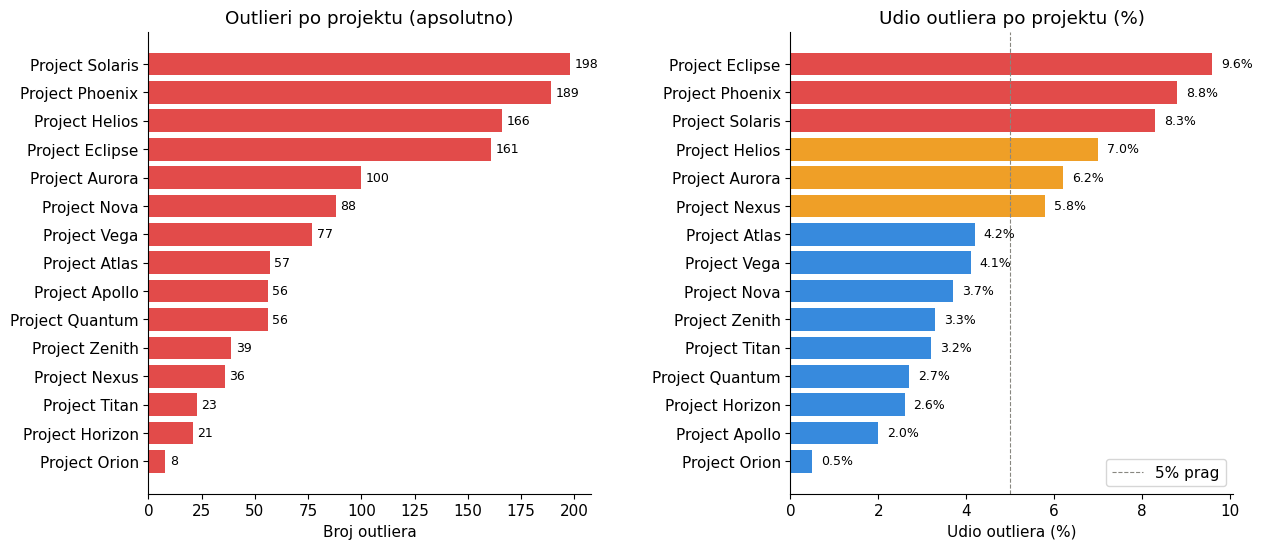

In [13]:
proj_out = outlieri.groupby('projekt').size().reset_index(name='outlieri')
proj_all = df_all.groupby('projekt').size().reset_index(name='ukupno')
proj = proj_out.merge(proj_all, on='projekt')
proj['udio_pct'] = (proj['outlieri'] / proj['ukupno'] * 100).round(1)
proj = proj.sort_values('outlieri', ascending=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Apsolutni broj
ax1.barh(proj['projekt'], proj['outlieri'], color='#E24B4A')
ax1.set_xlabel('Broj outliera')
ax1.set_title('Outlieri po projektu (apsolutno)')
for i, (val, name) in enumerate(zip(proj['outlieri'], proj['projekt'])):
    ax1.text(val + 2, i, str(val), va='center', fontsize=9)

# Postotak
proj2 = proj.sort_values('udio_pct', ascending=True)
colors = ['#E24B4A' if v > 7 else '#EF9F27' if v > 5 else '#378ADD' for v in proj2['udio_pct']]
ax2.barh(proj2['projekt'], proj2['udio_pct'], color=colors)
ax2.set_xlabel('Udio outliera (%)')
ax2.set_title('Udio outliera po projektu (%)')
ax2.axvline(x=5, color='#888780', linestyle='--', linewidth=0.8, label='5% prag')
ax2.legend()
for i, val in enumerate(proj2['udio_pct']):
    ax2.text(val + 0.2, i, f'{val:.1f}%', va='center', fontsize=9)

plt.subplots_adjust(wspace=0.45)
plt.show()

### 7.9.2 Outlieri po prioritetu — koji prioriteti najduže čekaju?

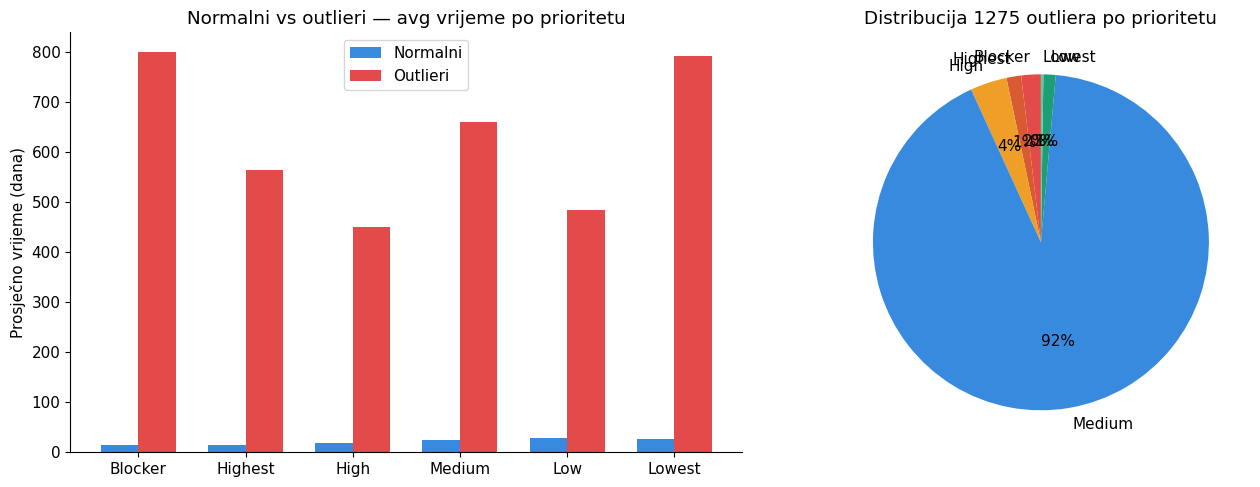

           avg_dana_outlieri  avg_dana_normalni  broj_outliera
prioritet                                                     
Blocker                800.3               15.5             24
Highest                564.0               13.8             18
High                   451.1               19.3             45
Medium                 661.6               25.1           1170
Low                    483.8               29.0             15
Lowest                 793.0               27.0              3


In [14]:
prio_order = ['Blocker', 'Highest', 'High', 'Medium', 'Low', 'Lowest']

# Usporedba: avg vrijeme outlieri vs normalni, po prioritetu
avg_out = outlieri.groupby('prioritet')['vrijeme_rjesavanja_sati'].mean() / 24
avg_norm = normalni.groupby('prioritet')['vrijeme_rjesavanja_sati'].mean() / 24
cnt_out = outlieri.groupby('prioritet').size()

prio_df = pd.DataFrame({
    'avg_dana_outlieri': avg_out,
    'avg_dana_normalni': avg_norm,
    'broj_outliera': cnt_out
}).reindex(prio_order).dropna()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Grouped bar: outlieri vs normalni
x = range(len(prio_df))
w = 0.35
ax1.bar([i - w/2 for i in x], prio_df['avg_dana_normalni'], w, label='Normalni', color='#378ADD')
ax1.bar([i + w/2 for i in x], prio_df['avg_dana_outlieri'], w, label='Outlieri', color='#E24B4A')
ax1.set_xticks(list(x))
ax1.set_xticklabels(prio_df.index)
ax1.set_ylabel('Prosječno vrijeme (dana)')
ax1.set_title('Normalni vs outlieri — avg vrijeme po prioritetu')
ax1.legend()

# Pie: distribucija outliera po prioritetu
colors_pie = {'Blocker':'#E24B4A', 'Highest':'#D85A30', 'High':'#EF9F27',
              'Medium':'#378ADD', 'Low':'#1D9E75', 'Lowest':'#5DCAA5'}
pie_colors = [colors_pie.get(p, '#888780') for p in prio_df.index]
ax2.pie(prio_df['broj_outliera'], labels=prio_df.index, colors=pie_colors,
        autopct='%1.0f%%', startangle=90)
ax2.set_title(f'Distribucija {len(outlieri)} outliera po prioritetu')

plt.tight_layout()
plt.show()

print(prio_df.round(1).to_string())

### 7.9.3 Outlieri po statusu — gdje zapinju?

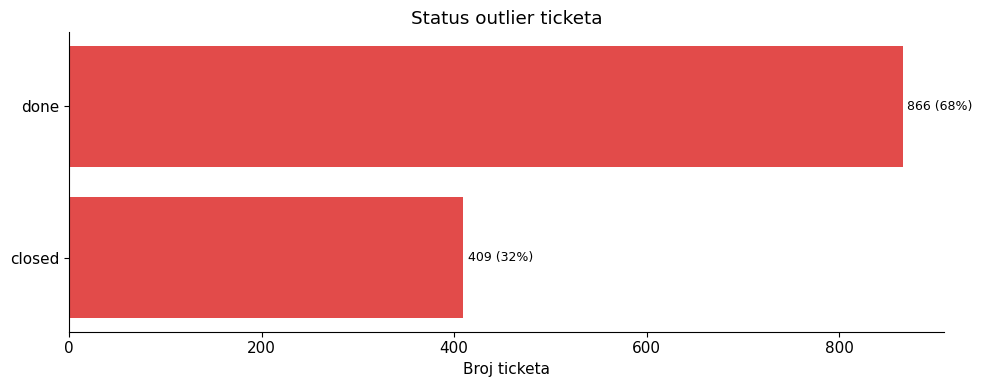

        outlieri  normalni  udio_outliera_pct
status                                       
done         866      6817               67.9
closed       409     17407               32.1


In [16]:
# Status distribucija: outlieri vs normalni
stat_out = outlieri['status'].value_counts()
stat_norm = normalni['status'].value_counts()

stat_df = pd.DataFrame({
    'outlieri': stat_out,
    'normalni': stat_norm
}).fillna(0).astype(int)
stat_df['udio_outliera_pct'] = (stat_df['outlieri'] / stat_df['outlieri'].sum() * 100).round(1)
stat_df = stat_df.sort_values('outlieri', ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
stat_plot = stat_df.head(6)
ax.barh(stat_plot.index, stat_plot['outlieri'], color='#E24B4A', label='Outlieri')
ax.set_xlabel('Broj ticketa')
ax.set_title('Status outlier ticketa')
ax.invert_yaxis()
for i, (val, pct) in enumerate(zip(stat_plot['outlieri'], stat_plot['udio_outliera_pct'])):
    ax.text(val + 5, i, f'{val} ({pct:.0f}%)', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print(stat_df.to_string())

### 7.9.4 Gdje outlieri troše vrijeme? Workflow breakdown

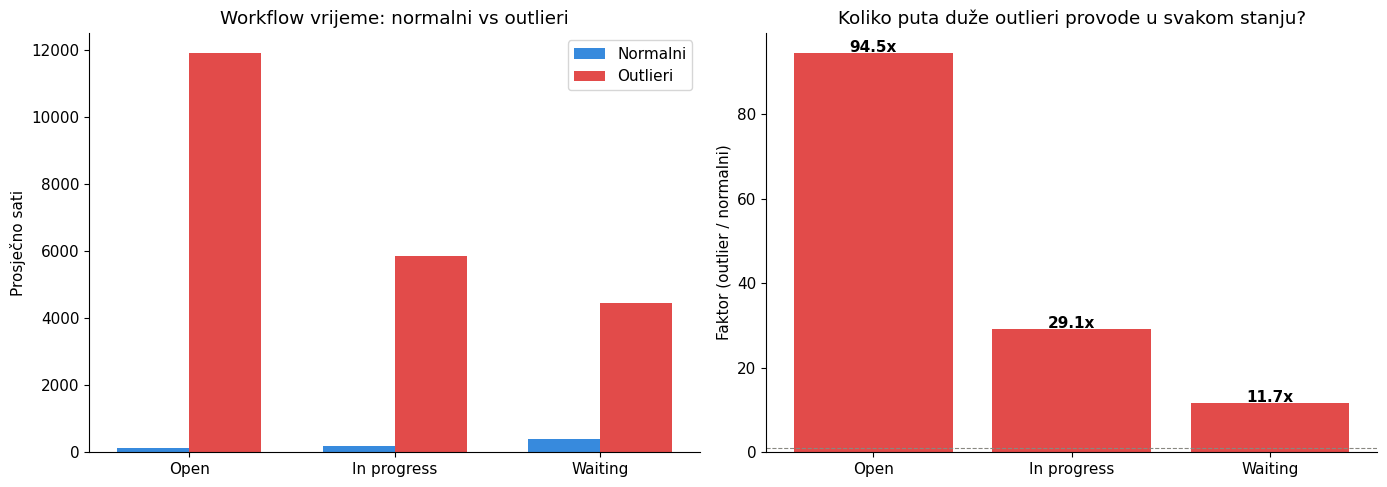

In [17]:
# Usporedba workflow vremena: outlieri vs normalni
wf_cols = ['sati_open', 'sati_in_progress', 'sati_waiting']
wf_labels = ['Open', 'In progress', 'Waiting']

avg_out_wf = [outlieri[c].mean() for c in wf_cols]
avg_norm_wf = [normalni[c].mean() for c in wf_cols]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

x = range(len(wf_labels))
w = 0.35
ax1.bar([i - w/2 for i in x], avg_norm_wf, w, label='Normalni', color='#378ADD')
ax1.bar([i + w/2 for i in x], avg_out_wf, w, label='Outlieri', color='#E24B4A')
ax1.set_xticks(list(x))
ax1.set_xticklabels(wf_labels)
ax1.set_ylabel('Prosječno sati')
ax1.set_title('Workflow vrijeme: normalni vs outlieri')
ax1.legend()

# Faktor povećanja
factors = [o/n if n > 0 else 0 for o, n in zip(avg_out_wf, avg_norm_wf)]
colors_f = ['#E24B4A' if f > 5 else '#EF9F27' if f > 2 else '#378ADD' for f in factors]
ax2.bar(wf_labels, factors, color=colors_f)
ax2.set_ylabel('Faktor (outlier / normalni)')
ax2.set_title('Koliko puta duže outlieri provode u svakom stanju?')
ax2.axhline(y=1, color='#888780', linestyle='--', linewidth=0.8)
for i, f in enumerate(factors):
    ax2.text(i, f + 0.2, f'{f:.1f}x', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

### 7.9.5 Heatmap — projekt × prioritet za outliere

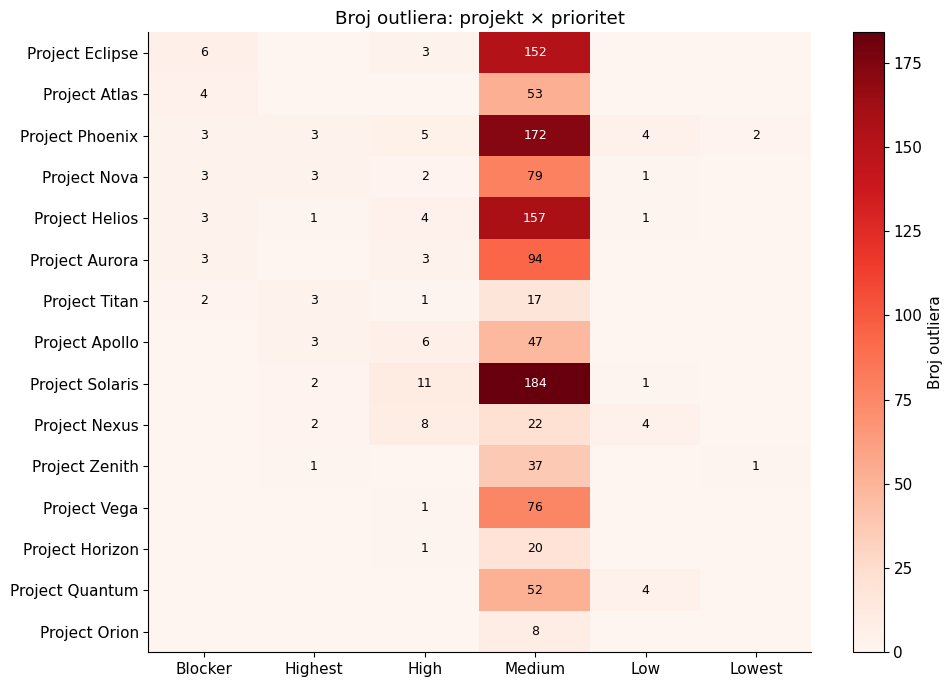


Top 5 kritičnih kombinacija:
                           cnt  avg_dana
projekt         prioritet               
Project Solaris Medium     184     502.0
Project Phoenix Medium     172    1078.0
Project Helios  Medium     157     919.0
Project Eclipse Medium     152     586.0
Project Aurora  Medium      94     575.0


In [18]:
prio_order = ['Blocker', 'Highest', 'High', 'Medium', 'Low', 'Lowest']
heatmap = outlieri.groupby(['projekt', 'prioritet']).size().unstack(fill_value=0)
heatmap = heatmap.reindex(columns=[p for p in prio_order if p in heatmap.columns])
heatmap = heatmap.sort_values(heatmap.columns.tolist(), ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(heatmap.values, cmap='Reds', aspect='auto')
ax.set_xticks(range(len(heatmap.columns)))
ax.set_xticklabels(heatmap.columns)
ax.set_yticks(range(len(heatmap.index)))
ax.set_yticklabels(heatmap.index)
ax.set_title('Broj outliera: projekt × prioritet')

for i in range(len(heatmap.index)):
    for j in range(len(heatmap.columns)):
        val = heatmap.values[i, j]
        if val > 0:
            color = 'white' if val > heatmap.values.max() * 0.6 else 'black'
            ax.text(j, i, str(val), ha='center', va='center', fontsize=9, color=color)

plt.colorbar(im, ax=ax, label='Broj outliera')
plt.tight_layout()
plt.show()

print(f"\nTop 5 kritičnih kombinacija:")
top = outlieri.groupby(['projekt', 'prioritet']).agg(
    cnt=('ticket_id', 'count'),
    avg_dana=('vrijeme_rjesavanja_sati', lambda x: (x.mean()/24).round(0))
).sort_values('cnt', ascending=False).head(5)
print(top.to_string())